# Analiza slovenskih gora

V nadaljevanju bom analizirala zbrane podatke o slovenskih gorah iz spletne strani [hribi.net](https://www.hribi.net).
Za vsako goro imamo podatke o njenem imenu, kateremu gorovju pripada, višini, številu ogledov na spletni strani, priljubljenosti (v %) in podatke o poteh, ki vodijo do vrha. Za vsako pot poznamo njeno ime, predviden čas (v min) in zahtevnost.
Analiza bo sestavljena iz dveh delov:
- Analiza gorovij in poti
- Analiza gora

Najprej uvozimo podatke iz datotek `gore.csv` in `poti.csv`.

In [159]:
import pandas as pd
gore = pd.read_csv("gore.csv", index_col="id")
poti = pd.read_csv("poti.csv", index_col="gora_id")

Tako zdaj izgledajo naši podatki o gorah.

In [184]:
gore

,ime,gorovje,visina,ogledi,priljubljenost,stevilo_poti
id,,,,,,
1,Veliki Snežnik,"Goriško, Notranjsko in Snežniško hribovje",1796,1052077,99,10
2,Mali Snežnik,"Goriško, Notranjsko in Snežniško hribovje",1694,439327,86,4
3,Mali Golak,"Goriško, Notranjsko in Snežniško hribovje",1495,710879,98,7
4,Srednji Golak,"Goriško, Notranjsko in Snežniško hribovje",1480,403846,83,2
5,Smrekov vrh,"Goriško, Notranjsko in Snežniško hribovje",1449,4490,40,1
...,...,...,...,...,...,...
2471,Ormoško jezero,"Strojna, Košenjak, Kozjak in Slovenske gorice",186,308,15,1
2472,Babičev mlin na Muri,"Strojna, Košenjak, Kozjak in Slovenske gorice",182,1843,31,2
2473,Gramoznica Krapje,"Strojna, Košenjak, Kozjak in Slovenske gorice",180,61,3,1


In tako podatki o poteh.

In [198]:
poti

,ime,cas,zahtevnost
gora_id,,,
1,Sviščaki - Veliki Snežnik,130,lahka označena pot
1,Kapetanova bajta - Veliki Snežnik,55,lahka označena pot
1,Leskova dolina - Veliki Snežnik,195,lahka označena pot
1,Snežniška Grda jama - Veliki Snežnik (čez Mali...,85,lahka označena pot
1,Gašperjev hrib - Veliki Snežnik,90,lahka označena pot
...,...,...,...
2472,Beltinci - Babičev mlin na Muri,95,lahka označena pot
2473,Zgornje Krapje - Gramoznica Krapje,20,lahka neoznačena steza
2474,Mota - Brod na Muri (Melinci) (od mrtvic do reke),45,lahka označena pot


## Analiza gorovij in poti

Najprej gore razvrstimo glede na gorovje, v katerem ležijo.

> Opomba: Poimenovanja na spletni strani niso povsem geografsko natančna. Gre bolj za regije kot pa za klasična gorovja, vendar bom zaradi skladnosti z virom uporabljala izraz *gorovje*.

In [236]:
gorovja = gore.groupby("gorovje").size().sort_values(ascending=False)
gorovja

gorovje
Julijske Alpe                                    613
Karavanke                                        394
Goriško, Notranjsko in Snežniško hribovje        309
Posavsko hribovje in Dolenjska                   307
Kamniško Savinjske Alpe                          297
Škofjeloško, Cerkljansko hribovje in Jelovica    145
Pohorje, Dravinjske gorice in Haloze             128
Strojna, Košenjak, Kozjak in Slovenske gorice    115
Polhograjsko hribovje in Ljubljana                92
Prekmurje                                         75
dtype: int64

<Axes: title={'center': 'Delež gora po gorovjih'}>

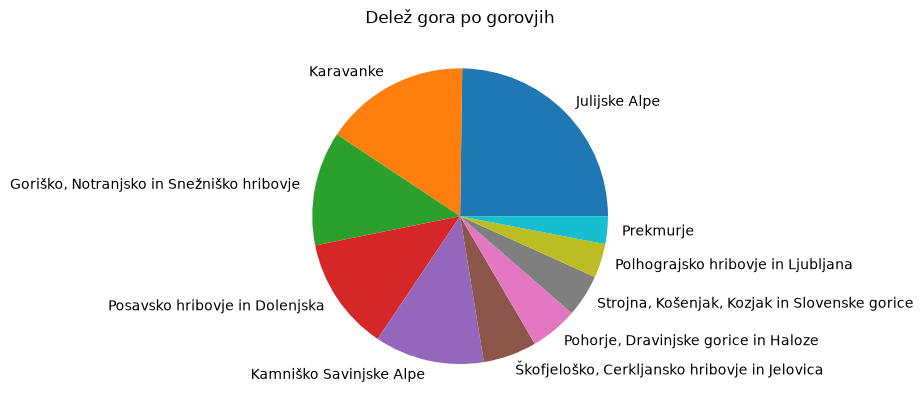

In [244]:
gorovja.plot.pie(title="Delež gora po gorovjih",)

Poglejmo koliko je povprečna višina posameznega gorovja, katero je najbolj priljbljeno in kolikšno je skupno število ogledov gor za vsako gorovje posebej.

In [245]:
gore.groupby("gorovje")["visina"].mean().round().sort_values(ascending=False)

gorovje
Julijske Alpe                                    1645.0
Kamniško Savinjske Alpe                          1349.0
Karavanke                                        1273.0
Škofjeloško, Cerkljansko hribovje in Jelovica     956.0
Pohorje, Dravinjske gorice in Haloze              913.0
Goriško, Notranjsko in Snežniško hribovje         764.0
Posavsko hribovje in Dolenjska                    644.0
Polhograjsko hribovje in Ljubljana                622.0
Strojna, Košenjak, Kozjak in Slovenske gorice     531.0
Prekmurje                                         295.0
Name: visina, dtype: float64

In [246]:
gore.groupby("gorovje")["priljubljenost"].mean().round().sort_values(ascending=False)

gorovje
Kamniško Savinjske Alpe                          72.0
Julijske Alpe                                    70.0
Polhograjsko hribovje in Ljubljana               67.0
Goriško, Notranjsko in Snežniško hribovje        63.0
Škofjeloško, Cerkljansko hribovje in Jelovica    60.0
Karavanke                                        59.0
Posavsko hribovje in Dolenjska                   50.0
Pohorje, Dravinjske gorice in Haloze             41.0
Strojna, Košenjak, Kozjak in Slovenske gorice    31.0
Prekmurje                                        24.0
Name: priljubljenost, dtype: float64

In [247]:
gore.groupby("gorovje")["ogledi"].sum().round().sort_values(ascending=False)

gorovje
Julijske Alpe                                    198472084
Kamniško Savinjske Alpe                          105212522
Karavanke                                         90456706
Goriško, Notranjsko in Snežniško hribovje         72249185
Posavsko hribovje in Dolenjska                    51147035
Škofjeloško, Cerkljansko hribovje in Jelovica     31572421
Polhograjsko hribovje in Ljubljana                25419682
Pohorje, Dravinjske gorice in Haloze              14713746
Strojna, Košenjak, Kozjak in Slovenske gorice      6104134
Prekmurje                                          1953776
Name: ogledi, dtype: int64

Iz rezultatov je razvidno, da višina gorovja močno vpliva na število ogledov, vendar pa ne določa nujno tudi priljubljenosti. Najvišja gorovja (Julijske Alpe, Kamniško-Savinjske Alpe in Karavanke) imajo največ ogledov, medtem ko se priljubljenost med njimi nekoliko razlikuje. Nižja in vzhodnejša gorovja imajo tako nižje vrednosti pri vseh treh lastnostih.

Sedaj pa poglejmo še kako so poti razporejene glede na čas.

<Axes: title={'center': 'Porazdelitev časa poti'}, xlabel='Čas v minutah', ylabel='Število poti'>

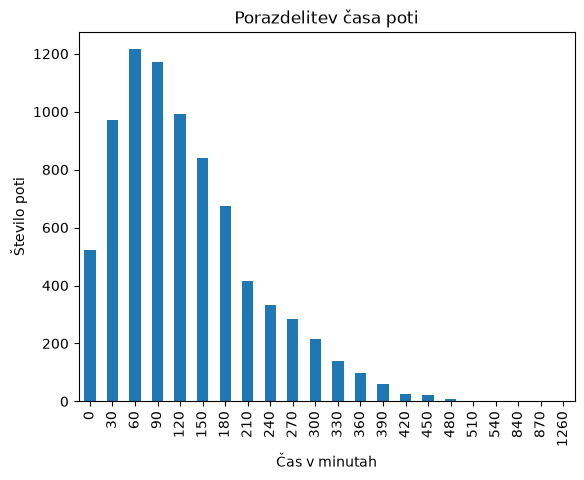

In [248]:
poti_po_casih = ((poti["cas"] // 30) * 30).value_counts().sort_index()
poti_po_casih.plot.bar(xlabel="Čas v minutah",
    ylabel="Število poti",
    title="Porazdelitev časa poti")

Iz grafa razberemo, da za veliko večino poti potrebujemo od 30 minut do 2 uri, poti daljših od 6 ur pa je zelo malo.

## Analiza gora

Da bomo gore lahko analizirali kar se da natančno, najprej združimo vse podatke v eno tabelo.

In [249]:
gore_poti = gore.merge(
    poti,
    left_on="id",
    right_on="gora_id",
    suffixes=("_gora", "_pot")
)
gore_poti

,ime_gora,gorovje,visina,ogledi,priljubljenost,stevilo_poti,ime_pot,cas,zahtevnost
0,Veliki Snežnik,"Goriško, Notranjsko in Snežniško hribovje",1796,1052077,99,10,Sviščaki - Veliki Snežnik,130,lahka označena pot
1,Veliki Snežnik,"Goriško, Notranjsko in Snežniško hribovje",1796,1052077,99,10,Kapetanova bajta - Veliki Snežnik,55,lahka označena pot
2,Veliki Snežnik,"Goriško, Notranjsko in Snežniško hribovje",1796,1052077,99,10,Leskova dolina - Veliki Snežnik,195,lahka označena pot
3,Veliki Snežnik,"Goriško, Notranjsko in Snežniško hribovje",1796,1052077,99,10,Snežniška Grda jama - Veliki Snežnik (čez Mali...,85,lahka označena pot
4,Veliki Snežnik,"Goriško, Notranjsko in Snežniško hribovje",1796,1052077,99,10,Gašperjev hrib - Veliki Snežnik,90,lahka označena pot
...,...,...,...,...,...,...,...,...,...
7989,Babičev mlin na Muri,"Strojna, Košenjak, Kozjak in Slovenske gorice",182,1843,31,2,Beltinci - Babičev mlin na Muri,95,lahka označena pot
7990,Gramoznica Krapje,"Strojna, Košenjak, Kozjak in Slovenske gorice",180,61,3,1,Zgornje Krapje - Gramoznica Krapje,20,lahka neoznačena steza
7991,Brod na Muri (Melinci),"Strojna, Košenjak, Kozjak in Slovenske gorice",175,196876,63,1,Mota - Brod na Muri (Melinci) (od mrtvic do reke),45,lahka označena pot
7992,Razkriški kot (sotočje Mure in Ščavnice),"Strojna, Košenjak, Kozjak in Slovenske gorice",169,585,22,2,Razkrižje - Razkriški kot (sotočje Mure in Šča...,75,lahka označena pot


Najprej poglejmo, če število poti vpliva na priljubljenost.

<Axes: xlabel='stevilo_poti', ylabel='priljubljenost'>

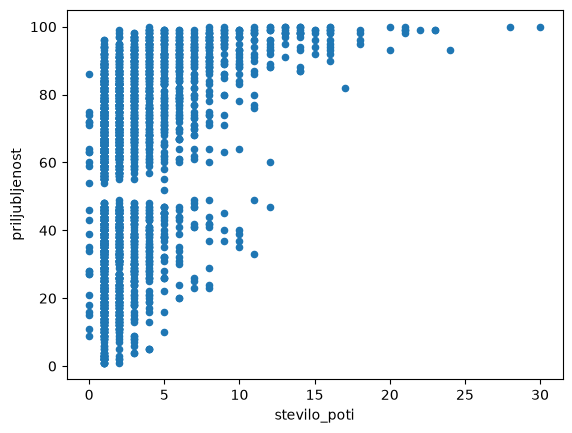

In [250]:
gore.plot.scatter(x="stevilo_poti", y="priljubljenost")

Opazimo, da so gore z majhnim številom poti različno priljubljene, medtem ko so gore z velikim številom poti praviloma zelo priljubljene.

Poglejmo, ali imajo višje gore več poti.

<Axes: title={'center': 'Povprečno število poti po višinskih razredih (500 m)'}, xlabel='visina'>

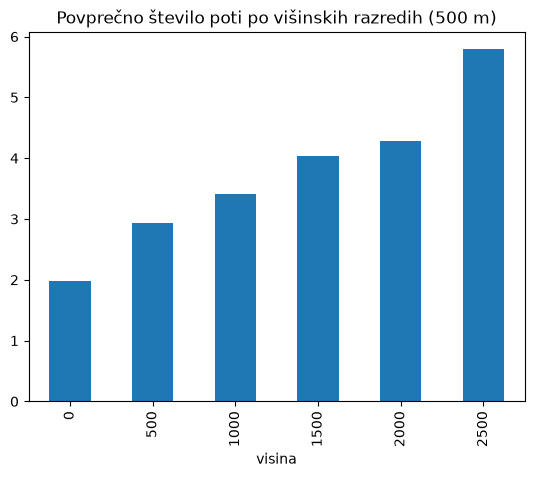

In [262]:
gore_po_visini = gore["visina"] // 500 * 500
poti_po_visini = gore.groupby(gore_po_visini)["stevilo_poti"].mean().sort_index()
poti_po_visini.plot.bar(title="Povprečno število poti po višinskih razredih (500 m)")

Očitno s povečevanjem višine gore narašča tudi število različnih dostopov.

Zanima nas tudi koliko časa traja povprečen vzpon na goro glede na njeno višino.

In [267]:
povprecen_cas = poti.groupby("gora_id")["cas"].mean()
gore2 = gore.join(poti.groupby("gora_id")["cas"].mean())

<Axes: title={'center': 'Povprečen čas poti po višinskih razredih (500 m)'}, xlabel='visina'>

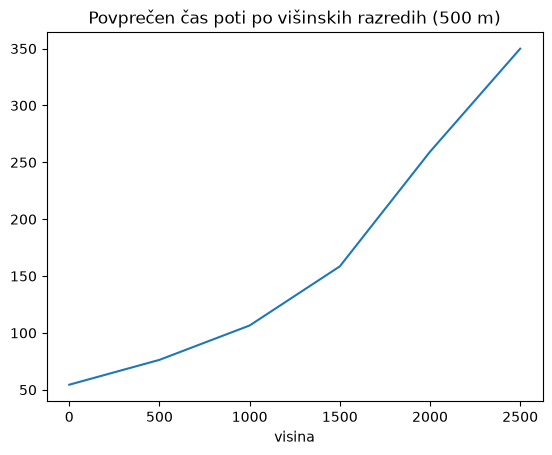

In [272]:
povprecen_cas_po_visini = gore2.groupby(gore_po_visini)["cas"].mean().sort_index()
povprecen_cas_po_visini.plot(title="Povprečen čas poti po višinskih razredih (500 m)")

Po pričakovanju so višje gore v povprečju dostopne po daljših poteh.